## Importing Libraries

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import re
from sklearn.preprocessing import LabelEncoder
from bs4 import BeautifulSoup
from hazm import stopwords_list
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score)
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout)

In [2]:
# Loading Data ...
df = pd.read_csv("digikala-comments.csv",low_memory=False)

## EDA

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6156289 entries, 0 to 6156288
Data columns (total 15 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   id                     int64  
 1   title                  object 
 2   body                   object 
 3   created_at             object 
 4   rate                   float64
 5   recommendation_status  object 
 6   is_buyer               bool   
 7   product_id             int64  
 8   advantages             object 
 9   disadvantages          object 
 10  likes                  int64  
 11  dislikes               int64  
 12  seller_title           object 
 13  seller_code            object 
 14  true_to_size_rate      object 
dtypes: bool(1), float64(1), int64(4), object(9)
memory usage: 663.4+ MB
None


true_to_size_rate        98.525524
disadvantages            93.303238
advantages               88.496235
title                    46.538783
recommendation_status    14.528655
seller_title              4.908493
seller_code               4.908493
body                      0.010347
rate                      0.000000
created_at                0.000000
id                        0.000000
is_buyer                  0.000000
product_id                0.000000
likes                     0.000000
dislikes                  0.000000
dtype: float64


                 id          rate    product_id         likes      dislikes
count  6.156289e+06  6.156289e+06  6.156289e+06  6.156289e+06  6.156289e+06
mean   3.704709e+07  3.648286e+00  3.908983e+06  4.503171e-01  8.687068e-02
std    1.393243e+07  1.861854e+00  3.015881e+06  2.294114e+00  8.313516e-01
min    9.815860e+05  0.000000e+00  7.602000e+03  0.000000e+00  0.000000e+00
25%    2.731234e+07  3.000000e+00  1.532375e+06  0.000000e+00  0.000000e+00
50%    4.044773e+07  4.000000e+00  3.183184e+06  0.000000e+00  0.000000e+00
75%    4.897122e+07  5.000000e+00  5.992988e+06  0.000000e+00  0.000000e+00
max    5.474516e+07  2.500000e+03  1.270221e+07  1.136000e+03  3.360000e+02
(6156289, 15)


1318


<Axes: >

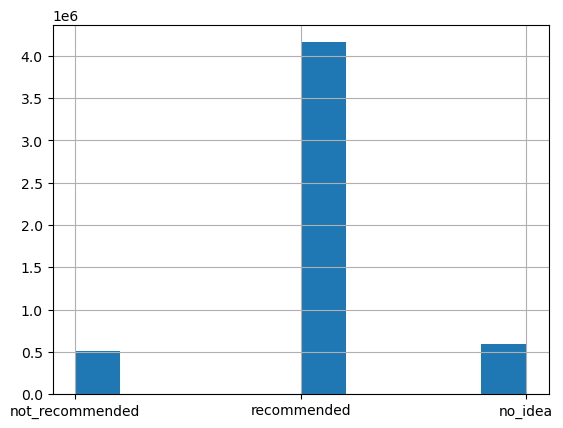

In [3]:
print("="*70)
print(df.info())
print("="*70)
print(df.isna().mean().mul(100).sort_values(ascending=False))
print("="*70)
print(df.describe())
print("="*70)
print(df.shape)
print("="*70)
print(df.duplicated().sum())
print("="*70)
df["recommendation_status"].hist()

## Preprocessing

In [3]:
df.drop(labels=["id","created_at","product_id","true_to_size_rate","disadvantages","advantages","seller_title","seller_code"],axis=1,inplace=True)
df["sentence"] = df["title"] + " " + df["body"]
df.drop(labels=["title","body"],axis=1,inplace=True)
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df["sentence"] = df["sentence"].astype(str)
df["sentence"] = df["sentence"].apply(
    lambda x: BeautifulSoup(x, "html.parser").get_text())
df["sentence"] = df["sentence"].str.lower()
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x))
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x))
df["sentence"] = df["sentence"].apply(
    lambda x: re.sub(r"\d+", " ", x))
stop_words = set(stopwords_list())
df["sentence"] = df["sentence"].apply(
    lambda x: " ".join(
        word for word in x.split()
        if word not in stop_words))
df = df[df["sentence"].str.strip() != ""]

In [5]:
print(df.info())
print("======================================")
print(df.isna().sum())
print("======================================")
df

<class 'pandas.core.frame.DataFrame'>
Index: 2598641 entries, 0 to 6156288
Data columns (total 6 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   rate                   float64
 1   recommendation_status  object 
 2   is_buyer               bool   
 3   likes                  int64  
 4   dislikes               int64  
 5   sentence               object 
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 121.4+ MB
None


rate                     0
recommendation_status    0
is_buyer                 0
likes                    0
dislikes                 0
sentence                 0
dtype: int64


,rate,recommendation_status,is_buyer,likes,dislikes,sentence
0,1.0,not_recommended,True,0,0,پیشنهاد نمیشود درد نمیخوره
1,0.0,recommended,True,1,0,بسته بد میتونست عنوان یه کالای فرهنگی بسته بشه
2,0.0,recommended,True,0,0,برس ریمل بسته بندیش کاربرد کیفیتشم خوبه روغن ز...
3,0.0,recommended,True,0,0,خوبه خوشرنگ نظرم خوبه یکم ظریفه رنگش خوشم اومد...
4,3.0,recommended,True,0,0,برس رنگ مو معمولیه اگه واسه خونه رنگ میخواین ا...
...,...,...,...,...,...,...
6156271,1.0,not_recommended,True,4,2,دستگاه های کپی اصل ارسال سلام دستگاهی های کپی ...
6156276,4.0,recommended,True,0,0,شارزر سیم ps خوبه کار اندازه
6156277,1.0,not_recommended,True,4,0,کالا عکس توضیحات مطابقت اصل میباشد کالا عکس تو...
6156281,4.0,recommended,True,2,0,اصلی میاد نمیدونم هیچوقت هیچی ایران ارزون نمیش...


## Modeling (TextCNN → Recommendation Classification)

### Creating small sample of data

In [4]:
df_small = df.sample(n=50000,random_state=42).reset_index(drop=True).copy()

In [6]:
df_small.to_csv("small_data.csv")

In [3]:
# Loading Data ...
df_small = pd.read_csv("small_data.csv",low_memory=False)

## Processing

In [4]:
def create_input(row):
    return (
        f"Review: {row['sentence']} "
        f"Rate: {row['rate']} "
        f"Likes: {row['likes']} "
        f"Dislikes: {row['dislikes']} "
        f"Buyer: {row['is_buyer']}")
df_small["text"] = df_small.apply(
    create_input,
    axis=1)
df_small.drop(labels=["sentence","rate","likes","dislikes","is_buyer"],axis=1,inplace=True)

In [5]:
X = df_small["text"].astype(str)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(
    df_small["recommendation_status"])
print(label_encoder.classes_)

['no_idea' 'not_recommended' 'recommended']


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp)

## Tokenization

In [7]:
max_words = 30000
max_len = 128
tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

## Text To Vector

In [8]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

## Padding

In [9]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_len,
    padding="post",
    truncating="post")
X_val_pad = pad_sequences(
    X_val_seq,
    maxlen=max_len,
    padding="post",
    truncating="post")
X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_len,
    padding="post",
    truncating="post")

## Build TextCNN

In [10]:
input_layer = Input(
    shape=(max_len,))
x = Embedding(
    input_dim=max_words,
    output_dim=128)(input_layer)
x = Conv1D(
    filters=128,
    kernel_size=3,
    activation="relu")(x)
x = GlobalMaxPooling1D()(x)
x = Dense(
    64,
    activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(
    3,
    activation="softmax")(x)
model = Model(
    inputs=input_layer,
    outputs=output)

E0000 00:00:1788116594.509323   10642 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1788116594.537004   10642 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Compile

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

## Summary

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 128, 128)       │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 126, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,897,731 (14.87 MB)

 Trainable params: 3,897,731 (14.87 MB)

 Non-trainable params: 0 (0.00 B)

## Callback

In [13]:
class MacroF1Callback(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__()
        self.X_val = X_val
        self.y_val = y_val
    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(
            self.X_val,
            verbose=0)
        y_pred = np.argmax(
            y_prob,
            axis=1)
        score = f1_score(
            self.y_val,
            y_pred,
            average="macro")
        print(f"\nValidation Macro F1: {score:.4f}")
f1_callback = MacroF1Callback(
    X_val_pad,
    y_val)

## Trainning (Trial and Error Tuning)

In [14]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(
        X_val_pad,
        y_val),
    epochs=1,
    batch_size=128,
    callbacks=[f1_callback],
    verbose=1)

  1/313 ━━━━━━━━━━━━━━━━━━━━ 24:45 5s/step - accuracy: 0.2734 - loss: 1.1118

  2/313 ━━━━━━━━━━━━━━━━━━━━ 1:40 324ms/step - accuracy: 0.5000 - loss: 1.0717

  3/313 ━━━━━━━━━━━━━━━━━━━━ 1:38 317ms/step - accuracy: 0.5938 - loss: 1.0313

  4/313 ━━━━━━━━━━━━━━━━━━━━ 1:33 302ms/step - accuracy: 0.6152 - loss: 1.0112

  5/313 ━━━━━━━━━━━━━━━━━━━━ 1:27 285ms/step - accuracy: 0.6484 - loss: 0.9730

...

310/313 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - accuracy: 0.8513 - loss: 0.3981

311/313 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8514 - loss: 0.3979

312/313 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8514 - loss: 0.3980

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8515 - loss: 0.3976


Validation Macro F1: 0.7359
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 259ms/step - accuracy: 0.8515 - loss: 0.3976 - val_accuracy: 0.8806 - val_loss: 0.3247


## Evalution

In [15]:
y_prob = model.predict(
    X_test_pad,
    verbose=0)
y_pred = np.argmax(
    y_prob,
    axis=1)
macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro")
print(
    "Macro F1:",
    macro_f1)

Macro F1: 0.7388253583214981


In [16]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
        digits=4))

                 precision    recall  f1-score   support

        no_idea     0.5676    0.4239    0.4853       545
not_recommended     0.8135    0.7633    0.7876       600
    recommended     0.9231    0.9650    0.9436      3855

       accuracy                         0.8818      5000
      macro avg     0.7680    0.7174    0.7388      5000
   weighted avg     0.8712    0.8818    0.8749      5000



## F1 Score = 0.7388